# Full Report Data POC

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [ ]:
import os
import sys
import datetime
from collections import defaultdict
import re
from html import escape


# WeasyPrint depends on native libraries (Pango, GObject, Cairo, ...) that
# Homebrew installs to /opt/homebrew/lib on Apple Silicon. That directory is
# not on macOS's default dlopen search path, so we add it here BEFORE importing
# weasyprint -- otherwise the import fails with:
#   OSError: cannot load library 'libgobject-2.0-0'
if sys.platform == "darwin":
    _brew_lib = "/opt/homebrew/lib"
    if os.path.isdir(_brew_lib):
        _existing = os.environ.get("DYLD_FALLBACK_LIBRARY_PATH", "")
        if _brew_lib not in _existing.split(":"):
            os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = (
                f"{_brew_lib}:{_existing}" if _existing else _brew_lib
            )

from dotenv import load_dotenv
import jinja2
from weasyprint import HTML
import pandas as pd


import common

## Environmental Variables

In [71]:
load_dotenv()
s3_bucket = os.environ.get("S3_BUCKET")
print(f"S3 Bucket: {s3_bucket}")
RUN_DB = f"{DATA_DIR}/logs.db"
print(f"Run database is {RUN_DB}")


S3 Bucket: kasbench-test-20260528-377288663341-us-east-1-an
Run database is ../data/verification-15-percentile-large-a/logs.db


## Constants

In [4]:
RUN = "verification-15-percentile-large-a"
SAMPLE_TRIAL = "trial0001" # Used to extract common infrastructure details
DATA_DIR = f"../data/{RUN}"
os.makedirs(DATA_DIR, exist_ok=True)
report_date = datetime.datetime.now(datetime.UTC)

TEMPLATE_DIR = "./templates"
FIGURE_DIR = "../figures"
OUTPUT_PATH = f"../output/fdr-{RUN}.pdf"

AUTOSCALER_LOOKUP = {"hpa": "Kubernetes Horizontal Pod Autoscaler (HPA)",
    "vpa": "Kubernetes Vertical Pod Autoscaler (VPA)",
    "keda": "Kubernetes Event-Driven Autoscaler (KEDA)",
    "none": "No autoscaler"}


params = {}

params["title"] =  "KASBench Full Disclosure Report"

## Benchmark Metadata Section

### Experiment Progress (experiment_progress.json)

In [5]:
experiment_progress = common.get_experiment_progress(s3_bucket, RUN)
experiment_progress

{'version': 'v1.0',
 'parameters': {'run_identifier': 'verification-15-percentile-large-a',
  'trial_prefix': 'trial',
  'autoscalers': ['hpa', 'keda', 'vpa', 'none'],
  'trials_per_autoscaler': 4,
  'run_duration': 30,
  'working_directory': '/data/benchmarks',
  's3_bucket': 'kasbench-test-20260528-377288663341-us-east-1-an',
  'aws_region': 'us-east-1',
  'var_files': ['large.tfvars'],
  'variables': ['spot=false'],
  'auto_approve': True,
  'runner_version': '0.2.22',
  'health_timeout': 6000,
  'rollout_timeout': 6000,
  'cluster_cidr_range': '10.244.0.0/16',
  'load_generator_image': 'kasbench/kasbench-load-generator:0.0.21',
  'role_params': {'back-office': {'baseLoadIntensity': 100,
    'baseDelayPercentage': 25,
    'spawnRate': 10},
   'portfolio-manager': {'baseLoadIntensity': 100,
    'baseDelayPercentage': 25,
    'spawnRate': 10},
   'trader': {'baseLoadIntensity': 100,
    'baseDelayPercentage': 25,
    'spawnRate': 10},
   'investor': {'baseLoadIntensity': 500,
    'bas

### Benchmark Database (benchmark.db)

In [ ]:
benchmark_db_path =f"{DATA_DIR}/benchmark.db"
common.download_benchmark_db(s3_bucket, RUN, benchmark_db_path)



### Tofu Outputs (tofu_outputs.json)

In [7]:
tofu_outputs = common.get_tofu_outputs(s3_bucket, RUN, SAMPLE_TRIAL)
tofu_outputs

{'ami_ids': {'sensitive': False,
  'type': ['object',
   {'amd64': 'string', 'ami_runner_amd64': 'string', 'arm64': 'string'}],
  'value': {'amd64': 'ami-0244585558b2aebd7',
   'ami_runner_amd64': 'ami-03a891c9de365d954',
   'arm64': 'ami-052bbac83b5bb0ab9'}},
 'benchmark_runner': {'sensitive': False,
  'type': ['object',
   {'ami_id': 'string',
    'architecture': 'string',
    'instance_id': 'string',
    'instance_type': 'string',
    'private_ip': 'string',
    'public_ip': 'string',
    'root_volume_id': 'string',
    'subnet_id': 'string'}],
  'value': {'ami_id': 'ami-03a891c9de365d954',
   'architecture': 'amd64',
   'instance_id': 'i-08583abccb0d2e84a',
   'instance_type': 'c6a.large',
   'private_ip': '10.0.1.124',
   'public_ip': '54.81.5.133',
   'root_volume_id': 'vol-06e7beed98c3e81ef',
   'subnet_id': 'subnet-01f3f81c585456b04'}},
 'control_plane': {'sensitive': False,
  'type': ['object',
   {'ami_id': 'string',
    'architecture': 'string',
    'instance_id': 'string',


### Run Details (run_details.json)

In [8]:
run_details = common.get_run_details(s3_bucket, RUN, SAMPLE_TRIAL)
run_details

{'timestamp': '2026-09-18T21:19:36.158408+00:00',
 'environment': {'HOST': '0.0.0.0',
  'PORT': 8080,
  'SSH_USER': 'ubuntu',
  'SSH_CONNECT_TIMEOUT': 30,
  'NODE_READINESS_TIMEOUT_SECONDS': 300,
  'NODE_READINESS_POLL_INTERVAL': 10,
  'HEALTH_CHECK_MAX_ATTEMPTS': 3,
  'HEALTH_CHECK_INTERVAL_SECONDS': 5,
  'RABBITMQ_IMAGE': 'rabbitmq:4-management',
  'HTTP_CONNECT_TIMEOUT': 10,
  'HTTP_READ_TIMEOUT': 30,
  'MANIFEST_FETCH_TIMEOUT': 30},
 'initialization': {'autoscaler': 'hpa',
  'controlPlaneNode': '10.0.1.52',
  'amdWorkerNodes': ['10.0.1.173'],
  'armWorkerNodes': ['10.0.1.150'],
  's3Bucket': 'kasbench-test-20260528-377288663341-us-east-1-an',
  'globecoUrl': 'http://kasb-20260918203417760500000012-65e557d8e291a45c.elb.us-east-1.amazonaws.com',
  'runIdentifier': 'verification-15-percentile-large-a',
  'trialIdentifier': 'trial0001',
  'clusterCidrRange': '10.244.0.0/16',
  'kubernetesVersion': '1.36.1',
  'loadGeneratorImage': 'kasbench/kasbench-load-generator:0.0.21',
  'runDurati

### Assembly

In [ ]:
metadata = {}

# Hardcode the benchmark name
metadata["benchmark_name"] = {"name": "Benchmark Name", "value": "KASBench"}

#Get the version from run_details.json
metadata["version"] = {"name": "Version", "value": experiment_progress["version"]} 

# Get start and end time from run_details.json
start_time = datetime.datetime.fromisoformat(run_details["status"]["startTime"].replace("Z", "+00:00"))
end_time = datetime.datetime.fromisoformat(run_details["status"]["endTime"].replace("Z", "+00:00"))
metadata["testing_dates"] = {"name": "Testing Dates", "value": f"{start_time.strftime('%Y-%m-%d %H:%M:%S')} UTC to {end_time.strftime('%Y-%m-%d %H:%M:%S')} UTC"}

start_time, end_time = common.get_start_end_time(s3_bucket, RUN)
metadata["testing_dates"] = {"name": "Testing Dates", "value": f"{start_time} UTC to {end_time} UTC"}

# Default the reporting date to now
metadata["reporting_date"] = {"name": "Reporting Date", "value": report_date.strftime('%Y-%m-%d %H:%M:%S') + " UTC"}

# Hardcode the benchmark application and cloud provider
metadata["benchmark_application"] = {"name": "Benchmark Application", "value": "GlobeCo"}
metadata["cloud_provider"] = {"name": "Cloud Provider", "value": "Amazon Web Services"}

# Get the region from experiment_progress.json
metadata["region"] = {"name": "Region", "value": experiment_progress["parameters"]["aws_region"]}

# Get the benchmark runner control plane, and worker nodes from tofu_outputs.json
metadata["bencmark_runner"] = {"name": "Benchmark Runner", 
    "value": tofu_outputs["benchmark_runner"]["value"]["instance_type"] + " (" + 
    tofu_outputs["benchmark_runner"]["value"]["architecture"] + ")"}
metadata["control_plane"] = {"name": "Control Plane", 
    "value": tofu_outputs["control_plane"]["value"]["instance_type"] + " (" + 
    tofu_outputs["control_plane"]["value"]["architecture"] + ")"}


worker_nodes = tofu_outputs["worker_nodes"]["value"]
amd_nodes = len(worker_nodes["amd64"])
arm_nodes = len(worker_nodes["arm64"])
if amd_nodes:
    amd_instance_type = worker_nodes["amd64"][0]["instance_type"]
    metadata["worker_nodes_amd"] = {"name": "Worker Nodes AMD", "value": f"{amd_nodes} x {amd_instance_type}"}
if arm_nodes:
        arm_instance_type = worker_nodes["arm64"][0]["instance_type"]
        metadata["worker_nodes_arm"] = {"name": "Worker Nodes ARM", "value": f"{arm_nodes} x {arm_instance_type}"}


# Hardcoded storage type (controlled by the Globeco Helm chart)
# metadata["storage_type_ios"] = {"name": "Storage Type", "value": "EBS gp3 3000 IOPS 125 MiB/s"}

# Get AMIs from tofu_outputs.json
ami_ids = tofu_outputs["ami_ids"]["value"]
metadata["ami_amd64"] = {"name": "AMD Worker AMI ID", "value": ami_ids["amd64"]}
metadata["ami_arm64"] = {"name": "ARM Worker AMI ID", "value": ami_ids["arm64"]}
metadata["ami_runner_amd64"] = {"name": "AMD Runner AMI ID", "value": ami_ids["ami_runner_amd64"]}

# Get Kubernetes version from run_details.json
kubernetes_version = run_details["initialization"]["kubernetesVersion"]
metadata["kubernetes_version"] = {"name": "Kubernetes Version", "value": kubernetes_version}

# Hardcoded container runtime (in installation script)
# metadata["Container Runtime"] = "Containerd"

# Get the autoscalers from experiment_progress.json
autoscalers = experiment_progress["parameters"]["autoscalers"]
# autoscalers = [a.upper() for a in autoscalers]
autoscalers = [AUTOSCALER_LOOKUP[a] for a in autoscalers]
metadata["autoscalers"] = {"name": "Autoscalers Evaluated", "value": ", ".join(autoscalers)}

# Get the number of trials from experiment_progress.json
trials_per_autoscaler = experiment_progress["parameters"]["trials_per_autoscaler"]
metadata["trials_per_autoscaler"] = {"name": "Trials Per Autoscaler", "value": trials_per_autoscaler}

metadata

{'benchmark_name': {'name': 'Benchmark Name', 'value': 'KASBench'},
 'version': {'name': 'Version', 'value': 'v1.0'},
 'testing_dates': {'name': 'Testing Dates',
  'value': '2026-09-18 20:33:12 UTC to 2026-09-19 10:16:10 UTC'},
 'reporting_date': {'name': 'Reporting Date',
  'value': '2026-09-22 13:52:03 UTC'},
 'benchmark_application': {'name': 'Benchmark Application',
  'value': 'GlobeCo'},
 'cloud_provider': {'name': 'Cloud Provider', 'value': 'Amazon Web Services'},
 'region': {'name': 'Region', 'value': 'us-east-1'},
 'bencmark_runner': {'name': 'Benchmark Runner', 'value': 'c6a.large (amd64)'},
 'control_plane': {'name': 'Control Plane', 'value': 'm8i.large (amd64)'},
 'worker_nodes_amd': {'name': 'Worker Nodes AMD', 'value': '1 x c6a.4xlarge'},
 'worker_nodes_arm': {'name': 'Worker Nodes ARM', 'value': '1 x c6g.4xlarge'},
 'ami_amd64': {'name': 'AMD Worker AMI ID', 'value': 'ami-0244585558b2aebd7'},
 'ami_arm64': {'name': 'ARM Worker AMI ID', 'value': 'ami-052bbac83b5bb0ab9'},
 

### Convert to table

In [11]:
df = pd.DataFrame(metadata).T
metadata_table_html = df.to_html(index=False, classes="data-table", 
    border=0, header=False)
params["metadata_table_html"] = metadata_table_html

## Software Versions

### Deployments and StatefulSets

In [52]:

def deployments_to_html(deployments_df):
    df = deployments_df.copy()

    # Sort/group as desired before suppressing duplicate deployment names.
    # If the existing order is already correct, this preserves it.
    df["Deployment_display"] = df["Deployment"].where(
        ~df["Deployment"].duplicated(),
        ""
    )

    # Build the combined Image / ImageID cell.
    # Escape values so characters such as &, <, and > remain valid HTML.
    df["Image_display"] = df.apply(
        lambda row: (
            f"{escape(str(row['Image']))}"
            f"<br>"
            f"<span class=\"image-id\">{escape(str(row['ImageID']))}</span>"
        ),
        axis=1
    )

    # Generate the HTML table.
    html = df[["Deployment_display", "Image_display"]].to_html(
        index=False,
        escape=False,
        header=True,
        classes="data-table compact",
        border=0
    )

    html = html.replace("Deployment_display", "Deployment")
    html = html.replace("Image_display", "Image")

    return html

def statefulset_to_html(statefulsets_df):
    df = statefulsets_df.copy()

    # Build the combined Image / ImageID cell.
    # Escape values so characters such as &, <, and > remain valid HTML.
    df["Image"] = df.apply(
        lambda row: (
            f"{escape(str(row['Image_original']))}"
            f"<br>"
            f"<span class=\"image-id\">{escape(str(row['ImageID']))}</span>"
        ),
        axis=1
    )

    # Generate the HTML table.
    html = df[["Stateful Set", "Image"]].to_html(
        index=False,
        escape=False,
        header=True,
        classes="data-table compact",
        border=0
    )

    return html

In [ ]:
images = common.get_images(s3_bucket, RUN, SAMPLE_TRIAL)
# combine images
deployments = defaultdict(set)
statefulsets = defaultdict(set)
for image in images:
    for workload in image["workloads"]:
        # if not workload["name"].startswith("globeco"):
        #     continue
        if workload["kind"] == "Deployment":
            for container in workload["containers"]:
                if match := re.match(r'kasbench\/(.+):', container["image"]):
                    name = match.group(1)
                else:
                    continue
                deployments[name] = {
                    "Deployment": container["name"],
                    "Image": container["image"],
                    "ImageID": container["imageID"]
                }
        elif workload["kind"] == "StatefulSet":
            for container in workload["containers"]:
                image = container["image"]
                # name is everything before the colon
                if ":" in image:
                    name = image.split(":")[0]
                statefulsets[container["name"]] = {
                    "Stateful Set": name,
                    "Image_original": image,
                    "ImageID": container["imageID"]
                }

# Convert the deployments dict to a DataFrame
deployments_df = pd.DataFrame(deployments).T

# Drop the index column
deployments_df = deployments_df.reset_index(drop=True)

# Sort by deployment
deployments_df = deployments_df.sort_values(by="Deployment")

# In the ImageID column, replace "@" with a space
deployments_df["ImageID"] = deployments_df["ImageID"].str.replace("@", " ", regex=False)

params["deployments_table_html"] = deployments_to_html(deployments_df)

# Convert the statefulsets dict to a DataFrame
statefulsets_df = pd.DataFrame(statefulsets).T

# Drop the index column
statefulsets_df = statefulsets_df.reset_index(drop=True)

# Remove duplicates
# statefulsets_df = statefulsets_df.drop_duplicates(subset=["Image"])
statefulsets_df = statefulsets_df.drop_duplicates()
# In the ImageID column, replace "@" with a space
statefulsets_df["ImageID"] = statefulsets_df["ImageID"].str.replace("@", " ", regex=False)

params["statefulsets_table_html"] = statefulset_to_html(statefulsets_df)



### Docker Images

In [84]:
benchmark_images = common.get_benchmark_images_df(s3_bucket, RUN, SAMPLE_TRIAL)
params["benchmark_images_table_html"] = benchmark_images.to_html(
    index=False,
    escape=False,
    header=True,
    classes="data-table compact",
    border=0
)
benchmark_images

,Component,Image_original,ImageID
0,KASBench Controller,kasbench/kasbench-controller:0.0.6,sha256:0816294976161de3279756584c5ee4061eafb86...
1,KASBench Runner,kasbench/kasbench-runner:0.2.22,sha256:a28c2f8b2a9ca961e2186d0b5e078e373065427...
2,KASBench Load Generator,kasbench/kasbench-load-generator:0.0.21,sha256:5e6ad9d312140a7f6e19f5792aa68b4a1c12d1e...


In [44]:
params["benchmark_images_table_html"] = images_to_html(benchmark_images)

### Helm Chart Versions

In [ ]:
helm_df = common.get_helm_versions(s3_bucket, RUN)

helm_df

,Name,Version,URL
aws-ebs-csi-driver,aws-ebs-csi-driver,2.66.0,https://kubernetes-sigs.github.io/aws-ebs-csi-...
aws-efs-csi-driver,aws-efs-csi-driver,4.5.0,https://kubernetes-sigs.github.io/aws-efs-csi-...
globeco,globeco,0.1.51,https://kasbench.github.io/globeco-helm
keda,keda,2.20.2,https://kedacore.github.io/charts
prometheus,prometheus,29.31.1,https://prometheus-community.github.io/helm-ch...


In [ ]:
params["helm_versions_table_html"] = helm_df.to_html(
    index=False,
    escape=False,
    header=True,
    classes="data-table compact",
    border=0
)



## Response Time, Failure Rate, and Roundtrip Metrics

In [ ]:
# Download the Locust database files and load them into a single database
common.download_and_load_locust_dbs(s3_bucket, RUN, RUN_DB, DATA_DIR)


In [ ]:
# Get the log as a dataframe
df =common.get_log_as_dataframe(RUN_DB)

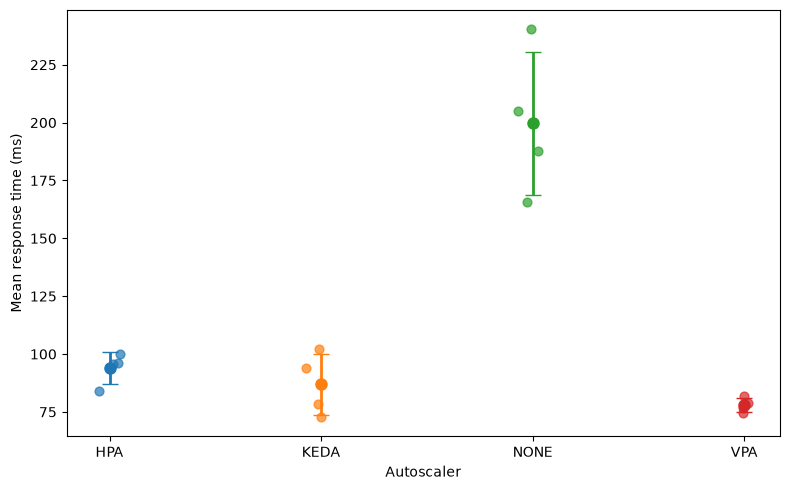

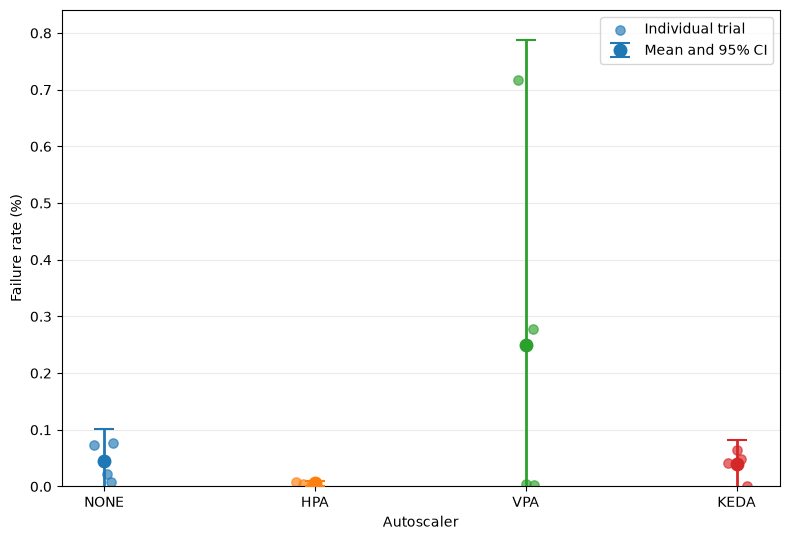

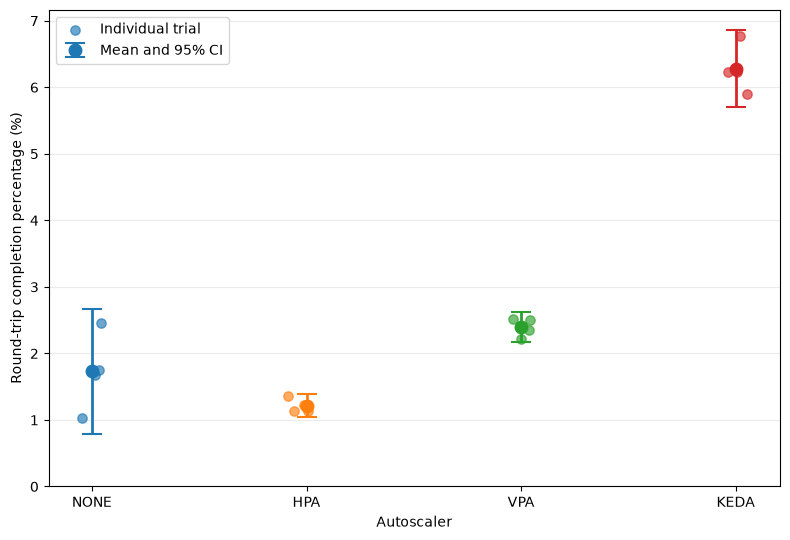

In [91]:
# Summarize by trial
trial_summary_df = common.get_trial_summary_df(df)

# Merge with roundtrip percentages
merged_trial_summary_df = common.merge_roundtrip_completion_percentage(None, s3_bucket, trial_summary_df, RUN)

# Summary by autoscaler
autoscaler_summary = common.get_autoscaler_summary(merged_trial_summary_df)

# Generate mean response time by autoscaler plot
_, _ = common.plot_mean_response_time_by_autoscaler(trial_summary_df, show=True)

# Generate failure rate by autoscaler plot
_, _ = common.plot_failure_rate_by_autoscaler(merged_trial_summary_df, show=True)

_, _ = common.plot_roundtrip_completion_by_autoscaler(merged_trial_summary_df, show=True)

In [105]:
params["merged_trial_summary_table_html"] = common.merged_trial_summary_df_to_html(merged_trial_summary_df)


<style type="text/css">
#T_626e1 th {
  text-align: center;
}
#T_626e1_row0_col0, #T_626e1_row0_col2, #T_626e1_row0_col3, #T_626e1_row0_col4, #T_626e1_row0_col5, #T_626e1_row0_col6, #T_626e1_row1_col0, #T_626e1_row1_col2, #T_626e1_row1_col3, #T_626e1_row1_col4, #T_626e1_row1_col5, #T_626e1_row1_col6, #T_626e1_row2_col0, #T_626e1_row2_col2, #T_626e1_row2_col3, #T_626e1_row2_col4, #T_626e1_row2_col5, #T_626e1_row2_col6, #T_626e1_row3_col0, #T_626e1_row3_col2, #T_626e1_row3_col3, #T_626e1_row3_col4, #T_626e1_row3_col5, #T_626e1_row3_col6, #T_626e1_row4_col0, #T_626e1_row4_col2, #T_626e1_row4_col3, #T_626e1_row4_col4, #T_626e1_row4_col5, #T_626e1_row4_col6, #T_626e1_row5_col0, #T_626e1_row5_col2, #T_626e1_row5_col3, #T_626e1_row5_col4, #T_626e1_row5_col5, #T_626e1_row5_col6, #T_626e1_row6_col0, #T_626e1_row6_col2, #T_626e1_row6_col3, #T_626e1_row6_col4, #T_626e1_row6_col5, #T_626e1_row6_col6, #T_626e1_row7_col0, #T_626e1_row7_col2, #T_626e1_row7_col3, #T_626e1_row7_col4, #T_626e1_row7_col5

In [95]:
merged_trial_summary_df.columns

Index(['autoscaler', 'trial_id', 'successful_requests', 'mean_response_time',
       'requests', 'failures', 'failure_rate', 'quantity_ordered',
       'quantity_placed', 'quantity_filled',
       'roundtrip_completion_percentage'],
      dtype='str')

## Generate the PDF

In [106]:
env = jinja2.Environment(loader=jinja2.FileSystemLoader(TEMPLATE_DIR))
template = env.get_template("fdr.html.jinja")

html_out = template.render(**params,**metadata)

# print(html_out)

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# base_url tells WeasyPrint where relative paths (e.g. the figure
# <img> srcs) should be resolved from.
HTML(string=html_out, base_url=TEMPLATE_DIR).write_pdf(
    OUTPUT_PATH, stylesheets=["style.css"]
)
print(f"Wrote {OUTPUT_PATH}")


Wrote ../output/fdr-verification-15-percentile-large-a.pdf
